# AG-HYPOPT · Trial 29

> ▶ RUN = execute this cell, never modify it  ·  ✍️ WRITE = replace the [placeholder] with your text  ·  ✍️ SET = put your value where the [placeholder] is, then run the cell. Full rules: `instructions.md`


## 1. ✍️ WRITE - Read and summarize

Read `context.md` (physics/model knowledge). If there are previous trials, read them too
(all `trial_XX` notebooks numbered lower than this one) and `trials.json` (the registry).
The current best is the recorded trial with the lowest objective; it is the reference
for the cell-3 choice.

Campaign state at trial_29. Twenty-eight trials recorded. Target rule wins, flat plateau (twenty-five samples
0.0803-0.0961, no trend); sim 0.1249 and power 0.1541 worse; h_f edges degrade. Two trials remain to the cap.


In [ ]:
# 2. ▶ RUN - Propose candidate trials (AGHyperopt)
TRIAL_ID = 'trial_29'   # auto-stamped by the generator; do not edit
import os

EXPERIMENT_DIR = os.getcwd()
SPACE_PATH = os.path.join(EXPERIMENT_DIR, 'space.json')
TRIALS_PATH = os.path.join(EXPERIMENT_DIR, 'trials.json')

MAX_TRIALS = 30    # campaign cap: stop generating new trials after this many (None = unlimited)

from ag_hypopt import AGHyperopt, trial_seed

opt = AGHyperopt(seed=trial_seed(TRIAL_ID))   # per-trial seed: fresh draws every trial
opt.fit(SPACE_PATH, TRIALS_PATH)
proposed_trials = opt.propose_trials(10)


phase = trials  (28/5 trials)
ID |     ei | params
 1 | 1.5184 | {"bandwidth_rule": "target", "h_f_scale": 5.267163186403404, "h_s_scale": 5.818460436708564}
 2 | 0.3646 | {"bandwidth_rule": "target", "h_f_scale": 4.0464280807823725, "h_s_scale": 3.6203291250977623}
 3 | 1.7621 | {"bandwidth_rule": "target", "h_f_scale": 4.520314614674929, "h_s_scale": 7.59779381343875}
 4 | 1.8280 | {"bandwidth_rule": "target", "h_f_scale": 3.7569575144455434, "h_s_scale": 11.474644496033903}
 5 | 1.7349 | {"bandwidth_rule": "power", "h_f_scale": 5.155863927016835, "h_s_scale": 5.868335528588576}
 6 | 0.7735 | {"bandwidth_rule": "power", "h_f_scale": 6.437556621172057, "h_s_scale": 7.75661209597556}
 7 | 1.6606 | {"bandwidth_rule": "target", "h_f_scale": 4.338999628012039, "h_s_scale": 7.176097619205764}
 8 | 0.3741 | {"bandwidth_rule": "power", "h_f_scale": 4.873046167907309, "h_s_scale": 9.72188241698474}
 9 |      - | {"bandwidth_rule": "power", "h_f_scale": 8.24273353002929, "h_s_scale": 3.6002858

## 3. ✍️ WRITE - Analyze and choose

Using the summary from cell 1 (previous trials + registry) and the candidate table from
cell 2, choose the ONE proposal that makes the most sense for the next trial. No hypothesis
and no expectation are needed: base the choice on what the trials have shown and on the
candidates themselves.

Highest-EI is #4 (target 3.757/11.475, EI 1.828) - the winning rule at a high sigma coefficient, a corner
not yet sampled (max tested h_s ~8.1); then #3 (target 4.520/7.598, 1.762) and #7 (4.339/7.176, 1.661).
Candidate #2 (target 4.046/3.620) is essentially exp6's default point and has the lowest EI (0.365), i.e.
the optimizer already treats it as known.

I choose candidate 4 (target, h_f_scale 3.757, h_s_scale 11.475).


In [ ]:
# 4. ✍️ SET - Chosen candidate (edit INDEX below, then run this cell)
INDEX = 4            # [Put the index here: 1-based candidate number from the table in cell 2]


chosen: {'bandwidth_rule': 'target', 'h_f_scale': 3.7569575144455434, 'h_s_scale': 11.474644496033903}
Running  1nW Trans05 ... 

μ 9.39 -> 6.12 | γ 8.5 -> 6.27 | NLL 0.15


Running  1nW Trans20 ... 

μ 17.32 -> 28.19 | γ 8.5 -> 5.38 | NLL 0.42


Running  1nW Trans60 ... 

...

Running  3nW Trans60 ... 

μ 103.20 -> 64.24 | γ 14.1 -> 14.05 | NLL 0.57


Running 3nW Trans100 ... 

μ 175.71 -> 94.61 | γ 14.1 -> 13.77 | NLL 0.55



Total: 7.9 min


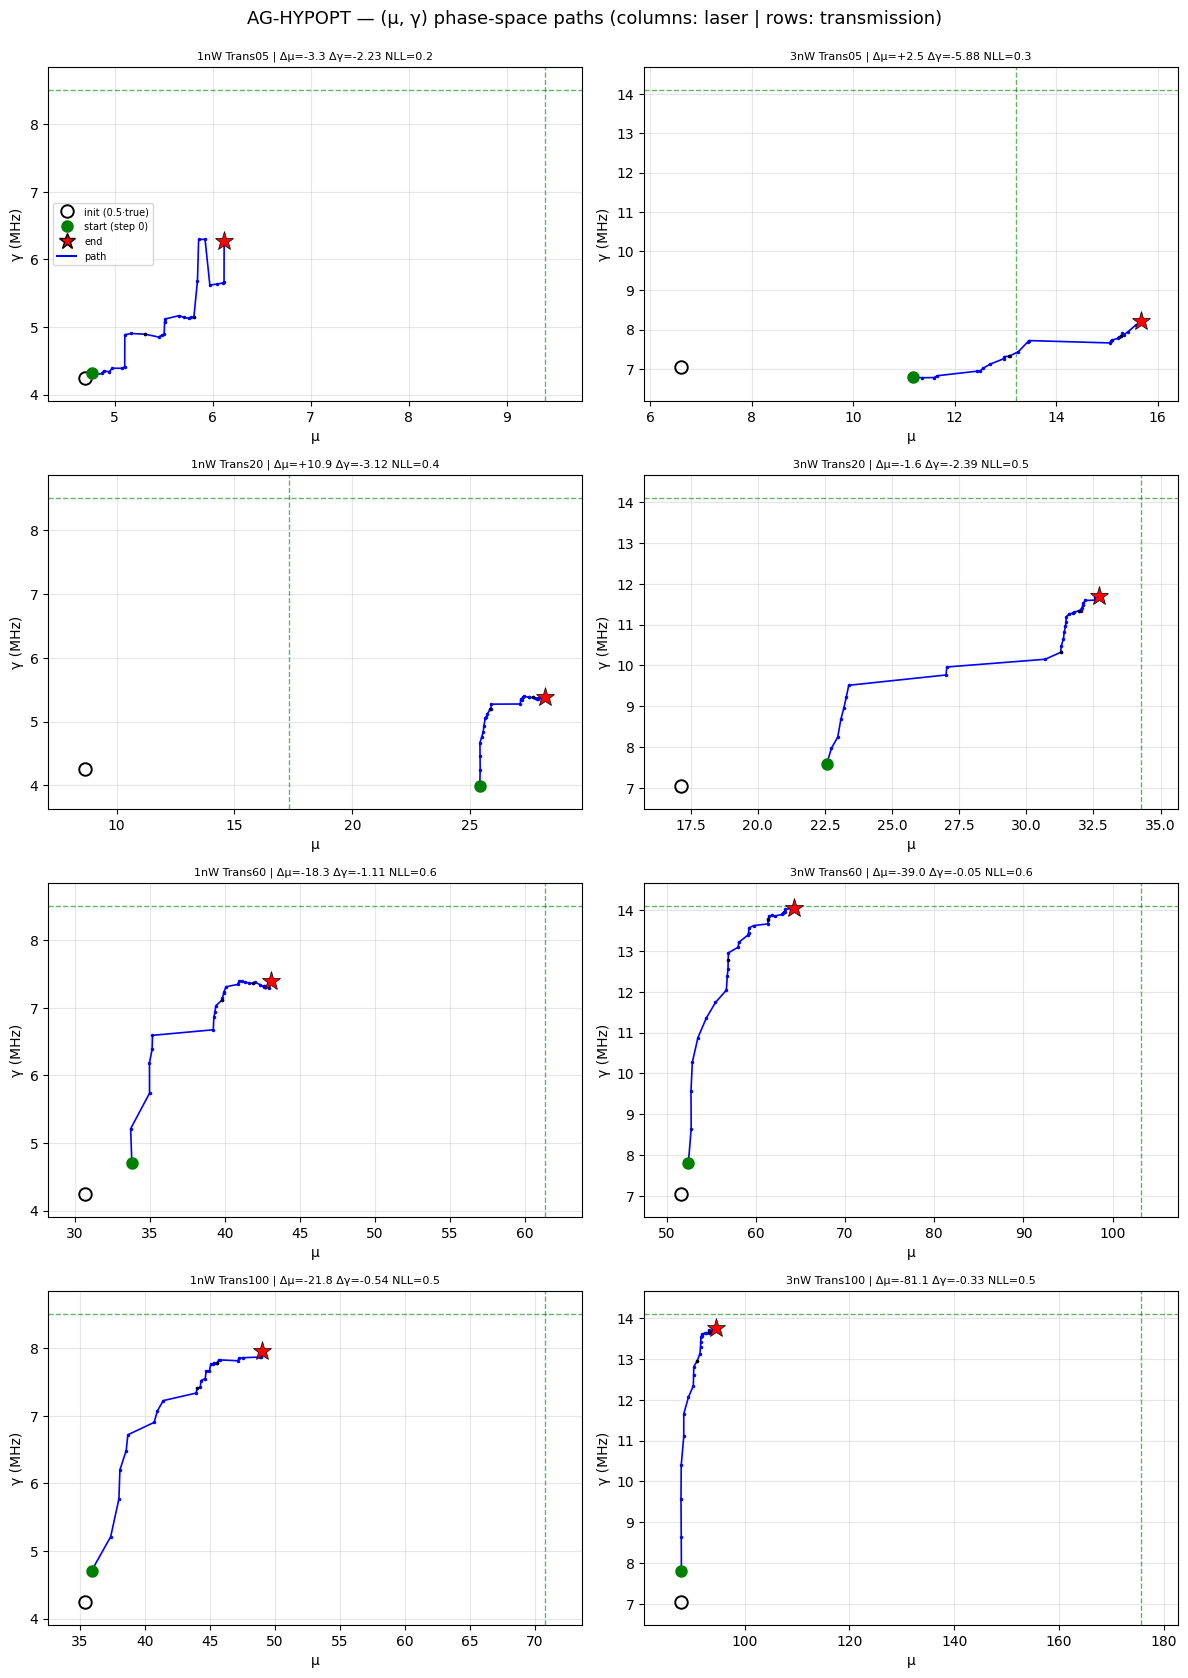

trial finished in 7.9 min
objective = 0.0863 ± 0.0261
exp              μ_true   μ_fit     Δμ% |   γ_true   γ_fit     Δγ%
1nW Trans05        9.39    6.12   -34.9 |     8.50    6.27   -26.2
1nW Trans20       17.32   28.19   +62.8 |     8.50    5.38   -36.7
1nW Trans60       61.37   43.10   -29.8 |     8.50    7.39   -13.0
1nW Trans100       70.82   49.06   -30.7 |     8.50    7.96    -6.4
3nW Trans05       13.20   15.68   +18.8 |    14.10    8.22   -41.7
3nW Trans20       34.28   32.69    -4.6 |    14.10   11.71   -16.9
3nW Trans60      103.20   64.24   -37.8 |    14.10   14.05    -0.3
3nW Trans100      175.71   94.61   -46.2 |    14.10   13.77    -2.4

weighted objective (T-graded, cap=1.0) = 0.0863 | diverged cells: 0
μ: RMSE 33.615 (rel 36.9%, bias -18.950) | γ: RMSE 2.660 (rel 23.1%, bias -1.955)


TypeError: unsupported operand type(s) for -: 'str' and 'str'

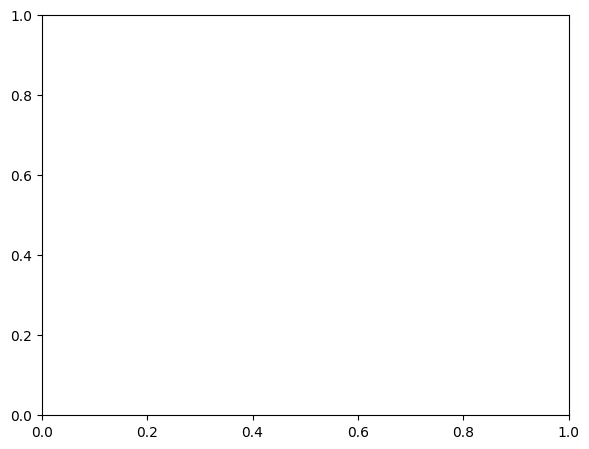

In [ ]:
# 5. ▶ RUN - Execute the chosen trial  (do not interrupt unless obviously broken)
assert INDEX is not None, 'INDEX not set: edit the SET cell (cell 4) before running this one'
assert 1 <= INDEX <= len(proposed_trials), f'bad INDEX: {INDEX}'
CHOSEN = proposed_trials[INDEX - 1]['params']
print('chosen:', CHOSEN)

from ag_hypopt import objective

import traceback, time
t0 = time.time()
try:
    loss, uncertainty, report = objective(CHOSEN)
    print(f'trial finished in {(time.time()-t0)/60:.1f} min')
    print(f'objective = {loss:.4f} ± {uncertainty:.4f}')
    print(report)
except Exception:
    traceback.print_exc()
    loss, uncertainty = None, None

# parallel coordinates: every recorded trial + this one (color = objective)
from ag_hypopt import plot_parallel
if loss is not None:
    plot_parallel(TRIALS_PATH, current={'config': CHOSEN, 'objective': loss})


## 6. ✍️ WRITE - Analyze the results

Record what actually happened in this trial: the measured objective, how the chosen
configuration behaved, and how that compares with the previous trials. No hypothesis to
confirm or refute, and no expectation to check: just the facts.

Objective = 0.0863 ± 0.0261, gamma finite on all 8 cells, diverged cells: 0. Config: bandwidth_rule =
target, h_f_scale = 3.757, h_s_scale = 11.475 - a new high-h_s corner (previous max ~8.1).

Usual pattern (mu under at most cells, +62.8 % at 1nW Trans20, +18.8 % at 3nW Trans05; gamma under
everywhere, high-T nearly exact). Twenty-sixth plateau sample at 0.0863 - even at h_s 11.5 the objective
sits inside the plateau, i.e. the sigma coefficient is flat all the way to the cap.

Execution note: same trailing `plot_parallel` diagnostic TypeError; objective computed and printed first,
so the trial stands. No rerun.

**Summary:** Trial 29 (target rule, h_f 3.757, h_s 11.475) scores objective 0.0863 ± 0.0261, the twenty-sixth flat-plateau sample, extending the flat h_s range up to the cap.
**Key insight:** Even at h_s 11.5 (near the cap) the target-rule objective stays in the plateau (0.0863), so the sigma coefficient is flat all the way to the boundary; exp6's 0.0803 remains the best.

Notes for Anuar (optional, not acted on): none new.


In [ ]:
# 7. ✍️ SET - Summary and key insight for the record (edit the strings below, then run)
SUMMARY = "Trial 29 (target rule, h_f 3.757, h_s 11.475) scores objective 0.0863 ± 0.0261, the twenty-sixth flat-plateau sample, extending the flat h_s range up to the cap."      # [Put the one-line summary here: copy it from cell 6]
KEY_INSIGHT = "Even at h_s 11.5 (near the cap) the target-rule objective stays in the plateau (0.0863), so the sigma coefficient is flat all the way to the boundary; exp6's 0.0803 remains the best."  # [Put the one-sentence key insight here: copy it from cell 6]


In [ ]:
# 8. ▶ RUN - Record the trial in trials.json
import json

assert SUMMARY is not None, 'SUMMARY not set: fill the SET cell (cell 7) first'
assert KEY_INSIGHT is not None, 'KEY_INSIGHT not set: fill the SET cell (cell 7) first'

entry = {
    'trial_id': TRIAL_ID,
    'config': CHOSEN,
    'objective': loss,
    'uncertainty': uncertainty,
    'summary': SUMMARY,
    'key_insight': KEY_INSIGHT,
    'notebook': f'{TRIAL_ID}.ipynb',
}
data = json.load(open(TRIALS_PATH))
assert not any(t.get('trial_id') == TRIAL_ID for t in data['trials']),     f'{TRIAL_ID} is already registered in trials.json'
data['trials'].append(entry)
json.dump(data, open(TRIALS_PATH, 'w'), indent=2)
best = min((t for t in data['trials'] if t.get('objective') is not None),
           key=lambda t: t['objective'], default=None)
print('saved', TRIAL_ID, '| current best:', best['trial_id'] if best else None)


saved trial_29 | current best: trial_05


In [ ]:
# 9. ▶ RUN - Generate the next trial (or end the campaign)
import os, re, json as _json

num = int(re.search(r'(\d+)$', TRIAL_ID).group(1))
nxt = num + 1
if MAX_TRIALS is not None and nxt > MAX_TRIALS:
    print(f'Campaign complete: cap MAX_TRIALS={MAX_TRIALS} reached after {TRIAL_ID}. Stop here.')
else:
    template_path = os.path.join(EXPERIMENT_DIR, 'template.ipynb')
    target = os.path.join(EXPERIMENT_DIR, f'trial_{nxt:02d}.ipynb')
    assert not os.path.exists(target), f'{target} already exists: refusing to overwrite'

    nb = _json.load(open(template_path))

    def _stamp(old, new):
        for c in nb['cells']:
            if old in ''.join(c.get('source', [])):
                c['source'] = [s.replace(old, new) for s in c['source']]
                return True
        raise RuntimeError(f'stamp target {old!r} not found in the template')

    _stamp('{N}', f'{nxt:02d}')
    _stamp('trial_XXX', f'trial_{nxt:02d}')
    _json.dump(nb, open(target, 'w'), indent=1)
    print(f'Created {os.path.basename(target)}. Open it and follow its cells from the top.')


Created trial_30.ipynb. Open it and follow its cells from the top.
